In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Membuat Fungsi Fuzzy

def comfort_fuzzy(suhu, kelembapan, angin, debu):
    temp_norm = np.interp(suhu, [0, 20, 25, 35, 40], [0, 0.3, 0.7, 1, 0.6])
    hum_norm = np.interp(kelembapan, [0, 30, 50, 70, 100], [0.2, 0.6, 0.8, 0.6, 0.3])
    wind_norm = np.interp(angin, [0, 10, 20, 30], [0.4, 0.7, 1, 0.8])
    dust_norm = np.interp(debu, [0, 50, 100, 150], [1, 0.7, 0.4, 0.1])

    comfort = (0.35*temp_norm + 0.25*hum_norm + 0.25*wind_norm + 0.15*dust_norm) * 100
    return comfort


#Membuat Dataset
np.random.seed(42)
n = 80

data = {
    'suhu': np.random.uniform(18, 38, n),
    'kelembapan': np.random.uniform(35, 90, n),
    'angin': np.random.uniform(4, 25, n),
    'partikel_debu': np.random.uniform(10, 140, n)
}

df = pd.DataFrame(data)

df['comfort_score'] = df.apply(lambda r: comfort_fuzzy(
    r['suhu'], r['kelembapan'], r['angin'], r['partikel_debu']), axis=1)

def comfort_label(score):
    if score < 50:
        return "Tidak Nyaman"
    elif score < 70:
        return "Cukup Nyaman"
    else:
        return "Nyaman"

df['comfort_level'] = df['comfort_score'].apply(comfort_label)

df.head(10)

,suhu,kelembapan,angin,partikel_debu,comfort_score,comfort_level
0,25.490802,82.470688,11.723446,132.259616,58.786889,Cukup Nyaman
1,37.014286,69.281397,17.278422,134.010715,70.437502,Nyaman
2,32.639879,53.199391,17.304124,128.932371,78.096205,Nyaman
3,29.973170,38.495709,15.251268,58.120631,78.053350,Nyaman
4,21.120373,52.104028,5.896085,12.009360,61.452258,Cukup Nyaman
5,21.119890,52.885083,21.541352,130.681413,60.382419,Cukup Nyaman
6,19.161672,75.128340,10.736381,65.663939,50.920324,Cukup Nyaman
7,35.323523,70.065661,7.916889,135.665126,67.805526,Cukup Nyaman
8,30.022300,83.796701,4.856278,135.270597,57.792095,Cukup Nyaman
9,32.161452,60.971821,16.408752,120.891229,75.702922,Nyaman


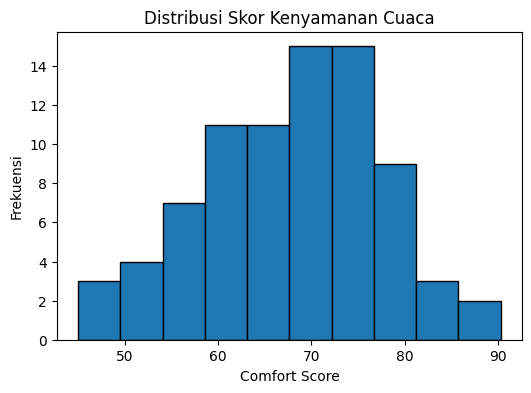

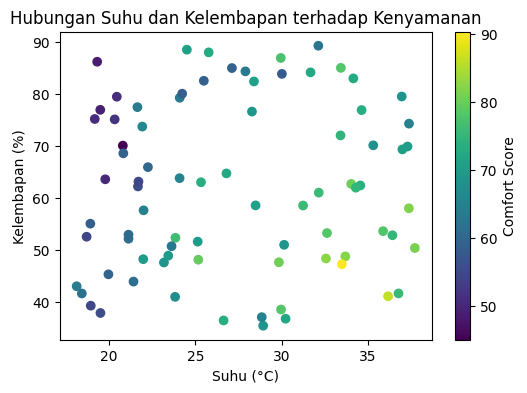

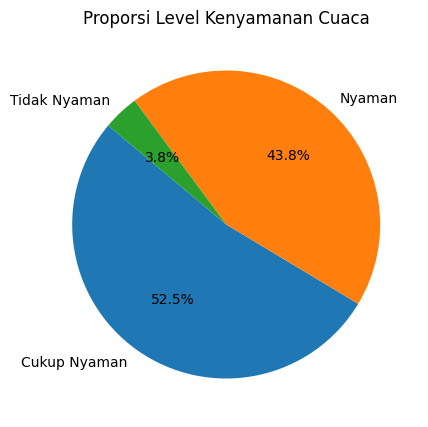

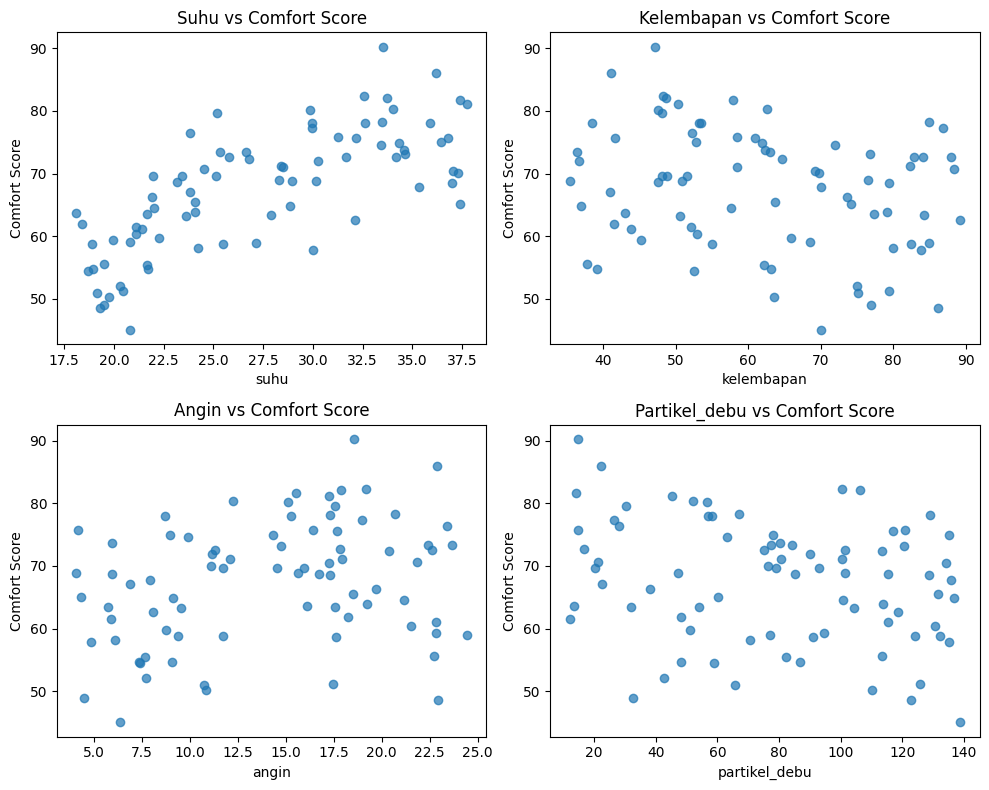

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['comfort_score'], bins=10, edgecolor='black')
plt.title('Distribusi Skor Kenyamanan Cuaca')
plt.xlabel('Comfort Score')
plt.ylabel('Frekuensi')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['suhu'], df['kelembapan'], c=df['comfort_score'], cmap='viridis')
plt.colorbar(label='Comfort Score')
plt.xlabel('Suhu (°C)')
plt.ylabel('Kelembapan (%)')
plt.title('Hubungan Suhu dan Kelembapan terhadap Kenyamanan')
plt.show()


plt.figure(figsize=(5,5))
df['comfort_level'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.ylabel('')
plt.title('Proporsi Level Kenyamanan Cuaca')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()
cols = ['suhu', 'kelembapan', 'angin', 'partikel_debu']

for i, col in enumerate(cols):
    axes[i].scatter(df[col], df['comfort_score'], alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Comfort Score')
    axes[i].set_title(f'{col.capitalize()} vs Comfort Score')

plt.tight_layout()
plt.show()



In [ ]:
df.to_csv('kenyamanan_cuaca_dataset.csv', index=False)
with open('requirements.txt', 'w') as f:
  f.write("numpy\npandas\nmatplotlib\n")

print("File disimpan: kenyamanan_cuaca_dataset.csv dan requirements.txt")

File disimpan: kenyamanan_cuaca_dataset.csv dan requirements.txt
